In [1]:
library(glmmTMB)
library(ggplot2)
library(ggeffects)
library(emmeans)
library(broom.mixed)
library(tidyverse)
library(patchwork)    # for combining plots

Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.5     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
setwd('../..')

METHODS <- c("IDW_median_10000.tif", "NaturalNeighbor_median_10000.tif", "RBF_median_10000.tif", "TIN_median_10000.tif", "isoKrige_AIC_median_pred_10000.tif", "isoKrige_AIC_median_detrended_pred_10000.tif")
P_ADJUST <- "holm" # "holm" is uniformly more powerful than "bonferroni"
#   while still controlling FWER. Switch to "tukey"
#   if you prefer for balanced pairwise comparisons.
ALPHA <- 0.05
SEED <- 42

# Paths — adjust to your project structure
BASE_DIR <- getwd()
RMSE_PATH <- file.path(
  BASE_DIR,
  "analysis_data",
  "aggregated_rmse.csv"
)
CHAR_PATH <- file.path(
  BASE_DIR,
  "analysis_data",
  "survey_characteristics.csv"
)
OUT_DIR <- file.path(BASE_DIR, "model_outputs", "figures")
dir.create(OUT_DIR, recursive = TRUE, showWarnings = FALSE)

In [3]:
rmse_raw <- read_csv(RMSE_PATH, show_col_types = FALSE)
chars <- read_csv(CHAR_PATH, show_col_types = FALSE)

In [4]:
df <- rmse_raw %>%
  pivot_longer(
    cols      = all_of(METHODS),
    names_to  = "method",
    values_to = "mean_rmse"
  )

In [5]:
df <- df %>%
  left_join(chars, by = "survey") %>%
  mutate(
    method = factor(method, levels = METHODS),
    survey = factor(survey)
    # block = factor(block)       # Uncomment for block CV
  ) %>%
  drop_na(mean_rmse)

In [6]:
df

survey,method,mean_rmse,density,depth_cv,anisotropy
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
BA_01_KBB_20210427_CS,IDW_median_10000.tif,0.1999823,0.001659899,0.1307649,0.6597689
BA_01_KBB_20210427_CS,NaturalNeighbor_median_10000.tif,0.2200848,0.001659899,0.1307649,0.6597689
BA_01_KBB_20210427_CS,RBF_median_10000.tif,0.2238312,0.001659899,0.1307649,0.6597689
BA_01_KBB_20210427_CS,TIN_median_10000.tif,0.2076790,0.001659899,0.1307649,0.6597689
BA_01_KBB_20210427_CS,isoKrige_AIC_median_pred_10000.tif,0.3441726,0.001659899,0.1307649,0.6597689
BA_01_KBB_20210427_CS,isoKrige_AIC_median_detrended_pred_10000.tif,0.1930013,0.001659899,0.1307649,0.6597689
BH_04_TCE_20210421_CS,IDW_median_10000.tif,0.3280110,0.038015118,0.4468055,0.3892623
BH_04_TCE_20210421_CS,NaturalNeighbor_median_10000.tif,0.3814134,0.038015118,0.4468055,0.3892623
BH_04_TCE_20210421_CS,RBF_median_10000.tif,0.3946236,0.038015118,0.4468055,0.3892623


In [7]:
df <- df %>%
  mutate(
    density_z = scale(density)[, 1],
    depth_cv_z = scale(depth_cv)[, 1],
    anisotropy_z = scale(anisotropy)[, 1]
  )

cat("\n--- Data summary ---\n")
cat("Surveys:", n_distinct(df$survey), "\n")
cat("Methods:", levels(df$method), "\n")
cat("Observations:", nrow(df), "\n\n")


--- Data summary ---
Surveys: 102 
Methods: IDW_median_10000.tif NaturalNeighbor_median_10000.tif RBF_median_10000.tif TIN_median_10000.tif isoKrige_AIC_median_pred_10000.tif isoKrige_AIC_median_detrended_pred_10000.tif 
Observations: 612 



In [17]:
m_main <- glmmTMB(
  mean_rmse ~ method + density_z + depth_cv_z + anisotropy_z + (1 | survey),
  data = df,
  family = Gamma(link = "log"),
  REML = TRUE
)

# m_inter <- glmmTMB(
#   mean_rmse ~ method * (density_z + depth_cv_z + anisotropy_z) + (1 | survey),
#   data = df,
#   family = Gamma(link = "log"),
#   REML = TRUE
# )

m_full <- glmmTMB(
  mean_rmse ~ method * (density_z + depth_cv_z + anisotropy_z) + (1 | survey),
  data = df,
  family = Gamma(link = "log"),
  REML = TRUE
)

In [18]:
# Refit both with REML = FALSE for likelihood comparison
m_add  <- update(m_main, REML = FALSE)
m_full <- update(m_full, REML = FALSE)
anova(m_add, m_full)

,Df,AIC,BIC,logLik,deviance,Chisq,Chi Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
m_add,11,-26.13877,7.824791,24.06938,-48.13877,NA,NA,NA
m_full,26,-49.70341,30.574096,50.85170,-101.70341,53.56464,15,3.105388e-06


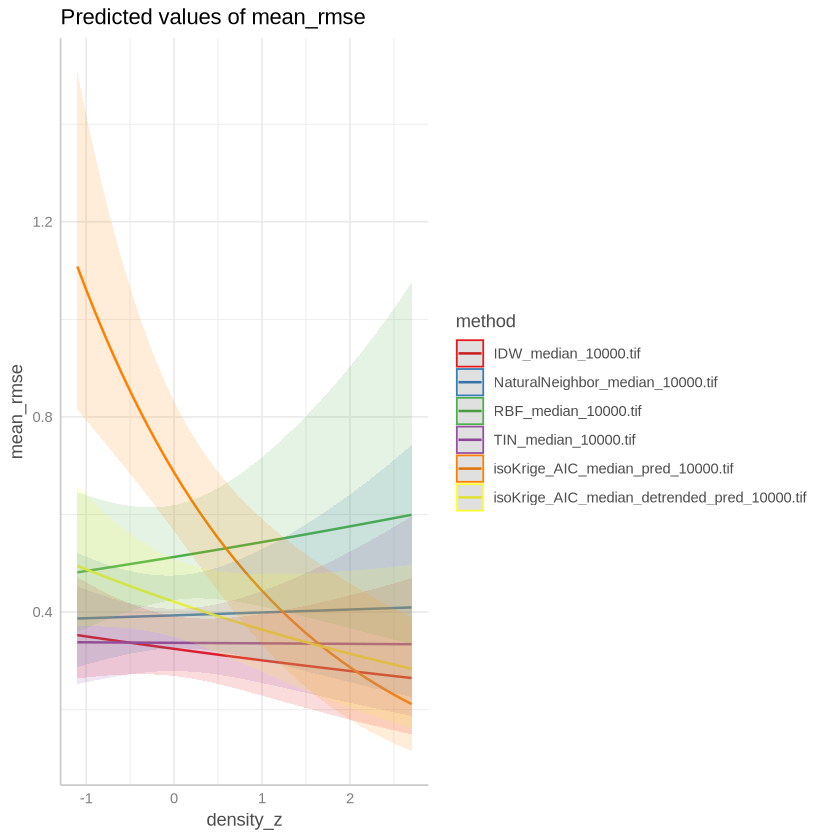

In [19]:
# This gives you one curve per method across the density range
ggpredict(m_full, terms = c("density_z [n=50]", "method")) |> plot()

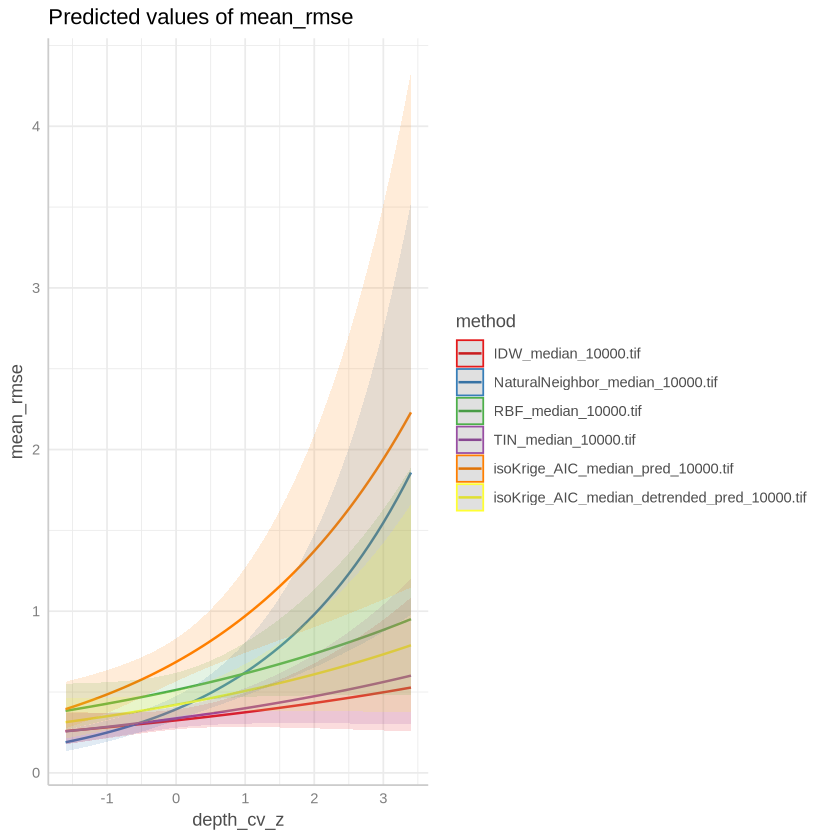

In [20]:
ggpredict(m_full, terms = c("depth_cv_z [n=50]", "method")) |> plot()

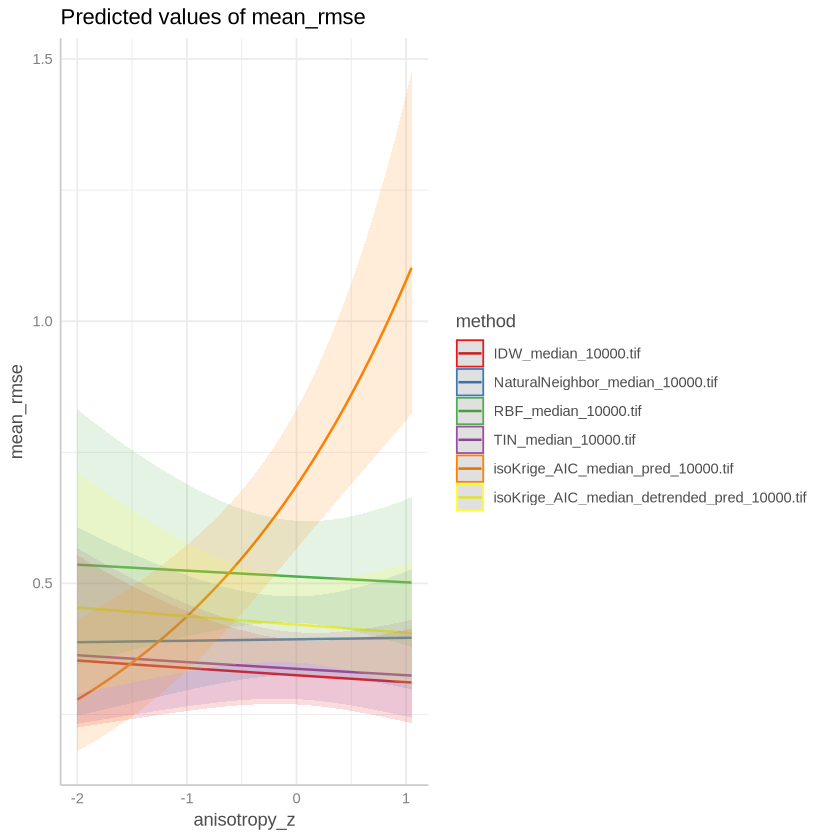

In [21]:
ggpredict(m_full, terms = c("anisotropy_z [n=50]", "method")) |> plot()

In [26]:
emmeans(m_full, pairwise ~ method, type = "response")

NOTE: Results may be misleading due to involvement in interactions



,(Intercept),methodNaturalNeighbor_median_10000.tif,methodRBF_median_10000.tif,methodTIN_median_10000.tif,methodisoKrige_AIC_median_pred_10000.tif,methodisoKrige_AIC_median_detrended_pred_10000.tif,density_z,depth_cv_z,anisotropy_z,methodNaturalNeighbor_median_10000.tif:density_z,⋯,methodNaturalNeighbor_median_10000.tif:depth_cv_z,methodRBF_median_10000.tif:depth_cv_z,methodTIN_median_10000.tif:depth_cv_z,methodisoKrige_AIC_median_pred_10000.tif:depth_cv_z,methodisoKrige_AIC_median_detrended_pred_10000.tif:depth_cv_z,methodNaturalNeighbor_median_10000.tif:anisotropy_z,methodRBF_median_10000.tif:anisotropy_z,methodTIN_median_10000.tif:anisotropy_z,methodisoKrige_AIC_median_pred_10000.tif:anisotropy_z,methodisoKrige_AIC_median_detrended_pred_10000.tif:anisotropy_z
(Intercept),9.229723e-03,-5.178521e-03,-5.169018e-03,-5.150536e-03,-5.270945e-03,-5.140815e-03,-9.510181e-06,1.444734e-05,1.666002e-05,1.587902e-05,⋯,-5.283968e-05,-5.041758e-06,-1.449400e-05,-1.189838e-05,1.844620e-06,2.049688e-06,2.197726e-06,5.262618e-07,-1.115412e-04,4.555546e-06
methodNaturalNeighbor_median_10000.tif,-5.178521e-03,1.040346e-02,5.187348e-03,5.176079e-03,5.256852e-03,5.116755e-03,2.037307e-05,-7.089850e-05,-8.859372e-06,-2.028932e-05,⋯,1.758864e-04,5.756692e-05,5.480137e-05,1.447622e-04,-2.287930e-05,-3.738724e-06,-2.708215e-05,-4.866418e-06,7.339628e-05,-1.171293e-05
methodRBF_median_10000.tif,-5.169018e-03,5.187348e-03,1.034448e-02,5.158862e-03,5.242103e-03,5.122741e-03,8.091367e-06,-2.978219e-06,1.348952e-06,-1.464185e-05,⋯,4.080252e-05,-1.748465e-05,5.547727e-06,-7.838837e-06,-1.965279e-05,-3.528642e-05,-3.376108e-05,-1.503655e-05,6.686964e-05,-1.690097e-05
methodTIN_median_10000.tif,-5.150536e-03,5.176079e-03,5.158862e-03,1.028638e-02,5.178487e-03,5.126800e-03,7.215950e-06,-1.289504e-05,-1.044128e-06,-8.944788e-06,⋯,3.787282e-05,6.387388e-06,9.881185e-06,2.075504e-05,-7.538635e-07,-8.981118e-06,-1.297781e-05,-4.238172e-06,3.003590e-05,-9.823542e-06
methodisoKrige_AIC_median_pred_10000.tif,-5.270945e-03,5.256852e-03,5.242103e-03,5.178487e-03,1.099475e-02,5.139021e-03,4.339817e-05,-3.084079e-05,-1.250316e-04,-2.144442e-05,⋯,1.693963e-04,5.340928e-06,4.222736e-05,-4.504855e-05,-2.878657e-05,3.011812e-05,5.887116e-05,2.298080e-05,6.820288e-04,7.664244e-06
methodisoKrige_AIC_median_detrended_pred_10000.tif,-5.140815e-03,5.116755e-03,5.122741e-03,5.126800e-03,5.139021e-03,1.035382e-02,-3.399119e-08,-3.791778e-06,5.138848e-06,1.664589e-06,⋯,1.375019e-06,-8.576224e-06,4.385258e-06,-1.715041e-06,1.899044e-05,-1.456162e-05,-1.788001e-05,-1.148255e-05,4.363950e-06,2.443843e-05
density_z,-9.510181e-06,2.037307e-05,8.091367e-06,7.215950e-06,4.339817e-05,-3.399119e-08,1.041538e-02,2.082032e-03,-3.631838e-03,-5.724865e-03,⋯,-1.191994e-03,-1.210335e-03,-1.209623e-03,-1.208153e-03,-1.219410e-03,2.100029e-03,2.094899e-03,2.095984e-03,2.136494e-03,2.097437e-03
depth_cv_z,1.444734e-05,-7.089850e-05,-2.978219e-06,-1.289504e-05,-3.084079e-05,-3.791778e-06,2.082032e-03,1.089191e-02,-1.546350e-03,-1.208696e-03,⋯,-6.653925e-03,-6.581576e-03,-6.571668e-03,-6.665446e-03,-6.512391e-03,7.722550e-04,7.902596e-04,7.851408e-04,7.779118e-04,7.854671e-04
anisotropy_z,1.666002e-05,-8.859372e-06,1.348952e-06,-1.044128e-06,-1.250316e-04,5.138848e-06,-3.631838e-03,-1.546350e-03,1.088850e-02,2.101335e-03,⋯,7.634205e-04,7.813815e-04,7.804889e-04,7.956905e-04,7.892465e-04,-6.241332e-03,-6.250253e-03,-6.226737e-03,-6.354889e-03,-6.229045e-03
methodNaturalNeighbor_median_10000.tif:density_z,1.587902e-05,-2.028932e-05,-1.464185e-05,-8.944788e-06,-2.144442e-05,1.664589e-06,-5.724865e-03,-1.208696e-03,2.101335e-03,1.238674e-02,⋯,2.650322e-03,1.209443e-03,1.218396e-03,1.194616e-03,1.186063e-03,-4.330500e-03,-2.098258e-03,-2.104357e-03,-2.113789e-03,-2.080289e-03


In [ ]:


# How does each method's slope differ for density?
emtrends(m_full, pairwise ~ method, var = "density_z")

In [23]:
theme_set(
  theme_minimal(base_size = 12) +
    theme(
      panel.grid.minor  = element_blank(),
      panel.grid.major.y = element_line(linewidth = 0.3, color = "grey85"),
      panel.grid.major.x = element_line(linewidth = 0.3, color = "grey85"),
      axis.title  = element_text(size = 11),
      plot.title  = element_text(face = "bold", size = 13),
      plot.subtitle = element_text(color = "grey40", size = 10),
      legend.position = "bottom"
    )
)

In [24]:
 
coef_tbl <- tidy(m_main, conf.int = TRUE, exponentiate = FALSE) |>
  filter(effect == "fixed") |>
  mutate(
    exp_estimate = exp(estimate),
    exp_conf.low = exp(conf.low),
    exp_conf.high = exp(conf.high),
    sig = ifelse(p.value < 0.05, "*", "")
  ) |>
  select(term, estimate, std.error, statistic, p.value,
         exp_estimate, exp_conf.low, exp_conf.high, sig)
 
# Print a clean table to the console
cat("\n=== Fixed Effects (log scale & exponentiated) ===\n\n")
print(
  coef_tbl |>
    mutate(across(c(estimate, std.error, statistic), \(x) round(x, 3)),
           p.value = ifelse(p.value < 0.001, "<0.001", round(p.value, 3)),
           across(c(exp_estimate, exp_conf.low, exp_conf.high), \(x) round(x, 3))) |>
    as.data.frame(),
  row.names = FALSE
)


=== Fixed Effects (log scale & exponentiated) ===

                                               term estimate std.error
                                        (Intercept)   -1.112     0.116
             methodNaturalNeighbor_median_10000.tif    0.178     0.123
                         methodRBF_median_10000.tif    0.456     0.122
                         methodTIN_median_10000.tif    0.034     0.122
           methodisoKrige_AIC_median_pred_10000.tif    0.781     0.128
 methodisoKrige_AIC_median_detrended_pred_10000.tif    0.258     0.122
                                          density_z   -0.087     0.092
                                         depth_cv_z    0.286     0.088
                                       anisotropy_z    0.056     0.092
 statistic p.value exp_estimate exp_conf.low exp_conf.high sig
    -9.551  <0.001        0.329        0.262         0.413   *
     1.455   0.146        1.195        0.940         1.520    
     3.740  <0.001        1.578        1.243     

`height` was translated to `width`.


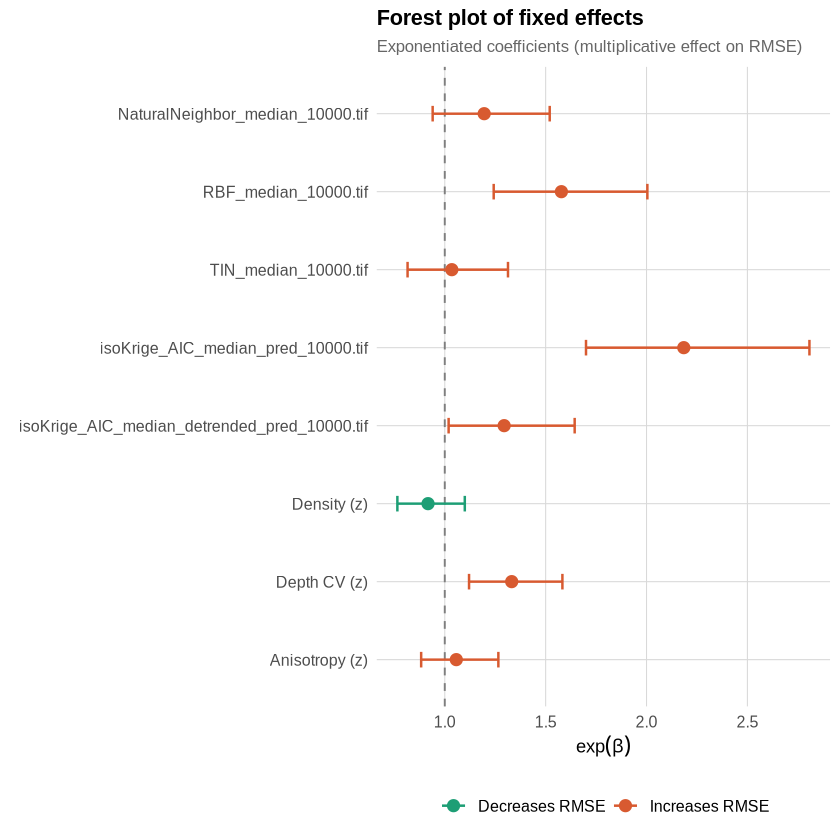

In [25]:
forest_df <- tidy(m_main, conf.int = TRUE, exponentiate = TRUE) |>
  filter(effect == "fixed", term != "(Intercept)") |>
  mutate(
    term = gsub("method", "", term),
    term = case_when(
      term == "density_z"    ~ "Density (z)",
      term == "depth_cv_z"   ~ "Depth CV (z)",
      term == "anisotropy_z" ~ "Anisotropy (z)",
      TRUE ~ term
    ),
    color = ifelse(estimate < 1, "Decreases RMSE", "Increases RMSE"),
    term  = factor(term, levels = rev(term))
  )
 
p_forest <- ggplot(forest_df, aes(x = estimate, y = term, color = color)) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "grey50") +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high),
                 height = 0.2, linewidth = 0.7) +
  geom_point(size = 3) +
  scale_color_manual(values = c("Decreases RMSE" = "#1D9E75",
                                "Increases RMSE" = "#D85A30"),
                     name = NULL) +
  labs(
    title    = "Forest plot of fixed effects",
    subtitle = "Exponentiated coefficients (multiplicative effect on RMSE)",
    x = expression(exp(beta)),
    y = NULL
  )
 
print(p_forest)

You are calculating adjusted predictions on the population-level (i.e.
  `type = "fixed"`) for a *generalized* linear mixed model.
  This may produce biased estimates due to Jensen's inequality. Consider
  setting `bias_correction = TRUE` to correct for this bias.
  See also the documentation of the `bias_correction` argument.



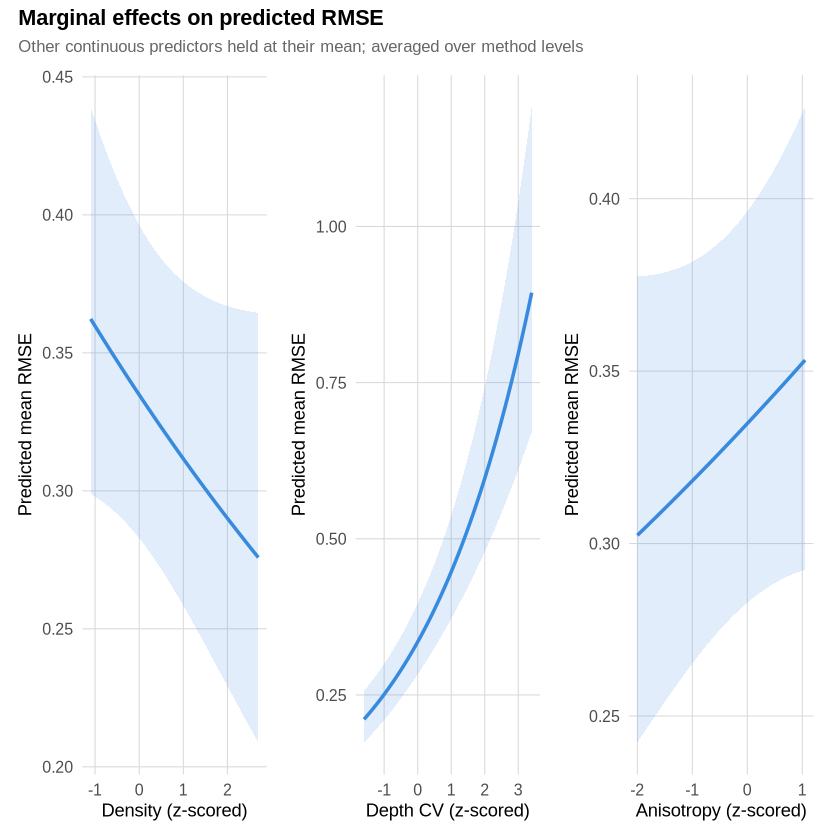

In [13]:
# Predictions holding other continuous predictors at their mean (0, since z-scored)
pred_density <- ggpredict(m_main, terms = "density_z [n=50]")
pred_depth   <- ggpredict(m_main, terms = "depth_cv_z [n=50]")
pred_aniso   <- ggpredict(m_main, terms = "anisotropy_z [n=50]")
 
make_me_plot <- function(pred_data, xlab) {
  ggplot(pred_data, aes(x = x, y = predicted)) +
    geom_ribbon(aes(ymin = conf.low, ymax = conf.high),
                fill = "#378ADD", alpha = 0.15) +
    geom_line(color = "#378ADD", linewidth = 1) +
    labs(x = xlab, y = "Predicted mean RMSE") +
    theme(plot.margin = margin(5, 10, 5, 5))
}
 
p_me_density <- make_me_plot(pred_density, "Density (z-scored)")
p_me_depth   <- make_me_plot(pred_depth,   "Depth CV (z-scored)")
p_me_aniso   <- make_me_plot(pred_aniso,   "Anisotropy (z-scored)")
 
p_marginal <- p_me_density + p_me_depth + p_me_aniso +
  plot_annotation(
    title    = "Marginal effects on predicted RMSE",
    subtitle = "Other continuous predictors held at their mean; averaged over method levels",
    theme = theme(
      plot.title    = element_text(face = "bold", size = 13),
      plot.subtitle = element_text(color = "grey40", size = 10)
    )
  )
 
print(p_marginal)

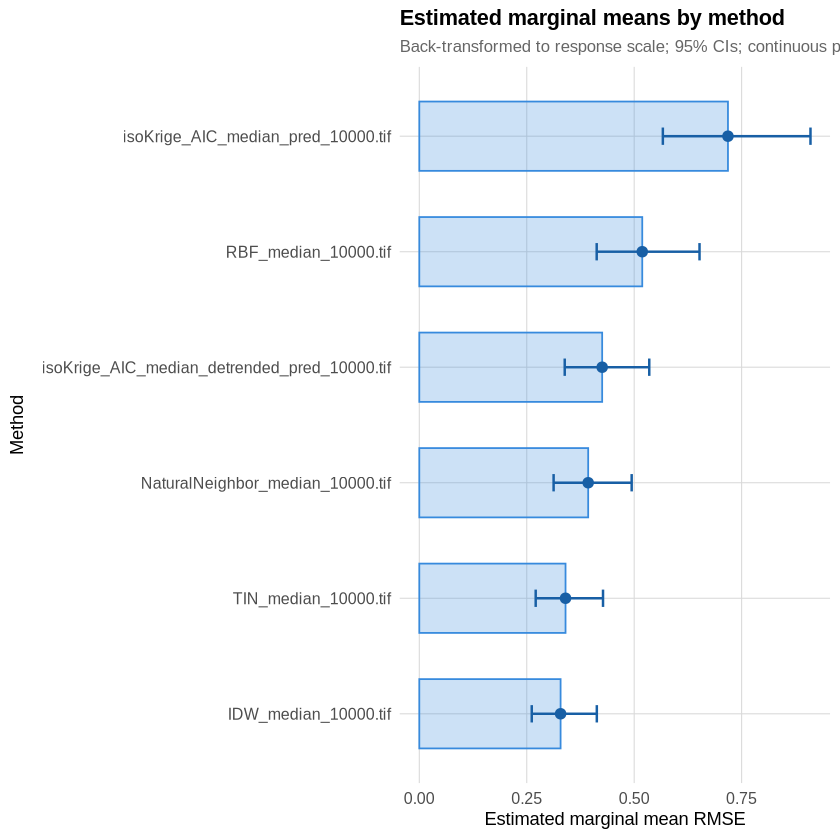

In [14]:
emm_method <- emmeans(m_main, ~ method, type = "response")
 
emm_df <- as.data.frame(emm_method)
# Column names depend on the family; typically "response", "SE", "lower.CL", "upper.CL"
# Adjust if your version of emmeans names them differently:
names(emm_df) <- gsub("asymp\\.LCL", "lower.CL", names(emm_df))
names(emm_df) <- gsub("asymp\\.UCL", "upper.CL", names(emm_df))
 
p_method <- ggplot(emm_df, aes(x = reorder(method, response), y = response)) +
  geom_col(fill = "#378ADD", alpha = 0.25, color = "#378ADD",
           linewidth = 0.5, width = 0.6) +
  geom_errorbar(aes(ymin = lower.CL, ymax = upper.CL),
                width = 0.15, linewidth = 0.7, color = "#185FA5") +
  geom_point(size = 2.5, color = "#185FA5") +
  labs(
    title    = "Estimated marginal means by method",
    subtitle = "Back-transformed to response scale; 95% CIs; continuous predictors at means",
    x = "Method",
    y = "Estimated marginal mean RMSE"
  ) +
  coord_flip()
 
print(p_method)

In [15]:
cat("\n=== Pairwise contrasts (ratio scale, Tukey-adjusted) ===\n\n")
print(pairs(emm_method, type = "response", adjust = "tukey"))


=== Pairwise contrasts (ratio scale, Tukey-adjusted) ===

 contrast                                                                         
 IDW_median_10000.tif / NaturalNeighbor_median_10000.tif                          
 IDW_median_10000.tif / RBF_median_10000.tif                                      
 IDW_median_10000.tif / TIN_median_10000.tif                                      
 IDW_median_10000.tif / isoKrige_AIC_median_pred_10000.tif                        
 IDW_median_10000.tif / isoKrige_AIC_median_detrended_pred_10000.tif              
 NaturalNeighbor_median_10000.tif / RBF_median_10000.tif                          
 NaturalNeighbor_median_10000.tif / TIN_median_10000.tif                          
 NaturalNeighbor_median_10000.tif / isoKrige_AIC_median_pred_10000.tif            
 NaturalNeighbor_median_10000.tif / isoKrige_AIC_median_detrended_pred_10000.tif  
 RBF_median_10000.tif / TIN_median_10000.tif                                      
 RBF_median_10000.tif / isoK